In [1]:
# Importation of libraries and setting of seaborn theme
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(context='talk', style='whitegrid', palette='deep', font='sans-serif')

Matplotlib is building the font cache; this may take a moment.


In [35]:
# Reading of both the pre-processing datasets
df_tr = pd.read_csv("../0.2_data_pre_processing/0.2.2_train/training_annotated.tsv", sep='\t')
df_bn = pd.read_csv("../0.2_data_pre_processing/0.2.2_train/benchmarking_annotated.tsv", sep='\t')

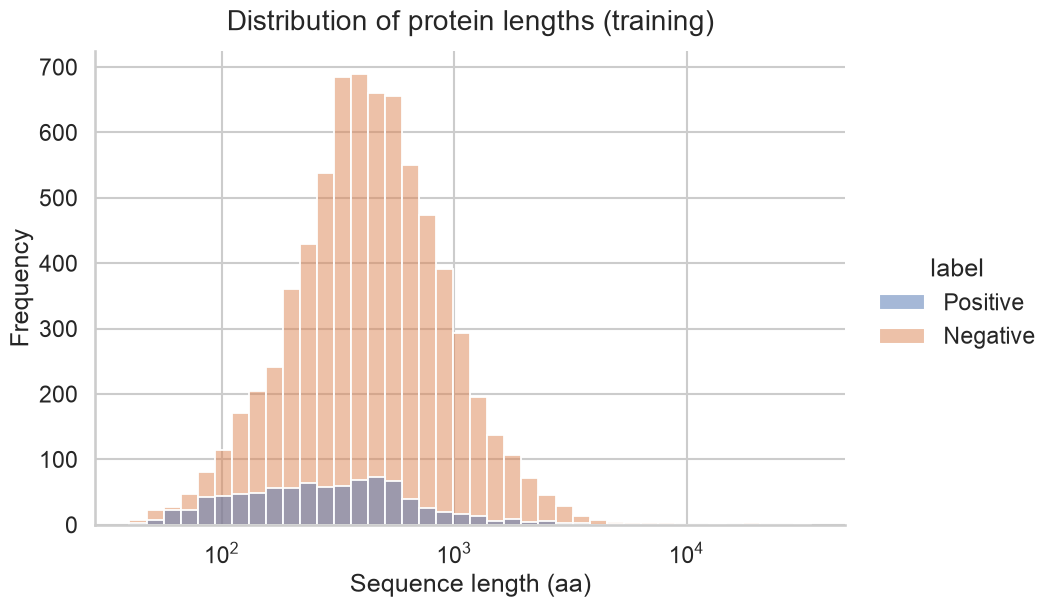

In [59]:
# PROTEIN LENGTHS DISTRIBUTION - TRAINING
df = df_tr.dropna(subset=["label"]).copy()
df["label"] = df["label"].map({1.0: "Positive", 0.0: "Negative"})     # We set labels as strings

g = sns.displot(
    data=df,
    x="length",
    hue="label",                                      # This way, we separate positives and negatives
    log_scale=True,
    bins=40,
    height=6,
    aspect=1.5
)
g.set_axis_labels("Sequence length (aa)", "Frequency")
g.ax.set_title("Distribution of protein lengths (training)", fontsize=20, pad=15)
plt.show()

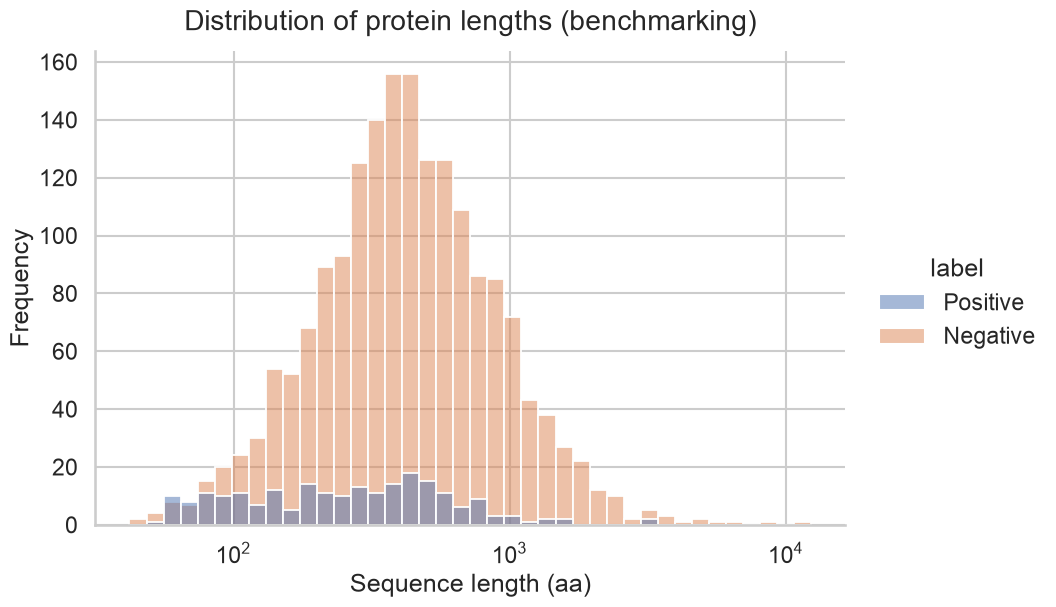

In [60]:
# PROTEIN LENGTHS DISTRIBUTION - BENCHMARKING
df = df_bn.dropna(subset=["label"]).copy()
df["label"] = df["label"].map({1.0: "Positive", 0.0: "Negative"})    # We set labels as strings

g = sns.displot(
    data=df,
    x="length",
    hue="label",                                      # This way, we separate positives and negatives
    log_scale=True,
    bins=40,
    height=6,
    aspect=1.5
)
g.set_axis_labels("Sequence length (aa)", "Frequency")
g.ax.set_title("Distribution of protein lengths (benchmarking)", fontsize=20, pad=15)
plt.show()

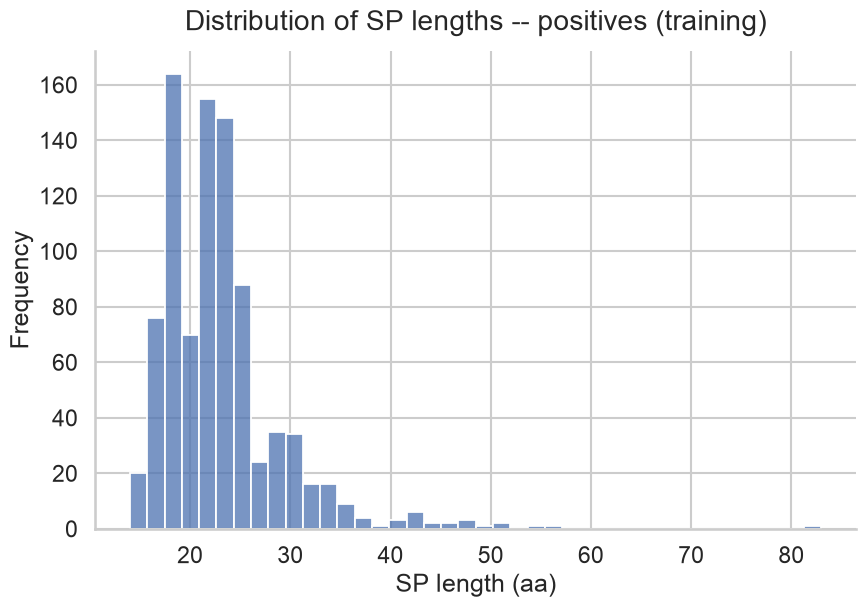

In [73]:
# SP LENGTHS DISTRIBUTION - TRAINING
df = df_tr.dropna(subset=["label"]).copy()
df["label"] = df["label"].map({1.0: "Positive"})       # We set labels as strings
positives = df[df['label'] == 'Positive']

g = sns.displot(
    data=positives,
    x="cleavage_site",                                       # This way, we separate positives and negatives
    bins=40,
    height=6,
    aspect=1.5,
)
g.set_axis_labels("SP length (aa)", "Frequency")
g.ax.set_title("Distribution of SP lengths -- positives (training)", fontsize=20, pad=15)
plt.show()

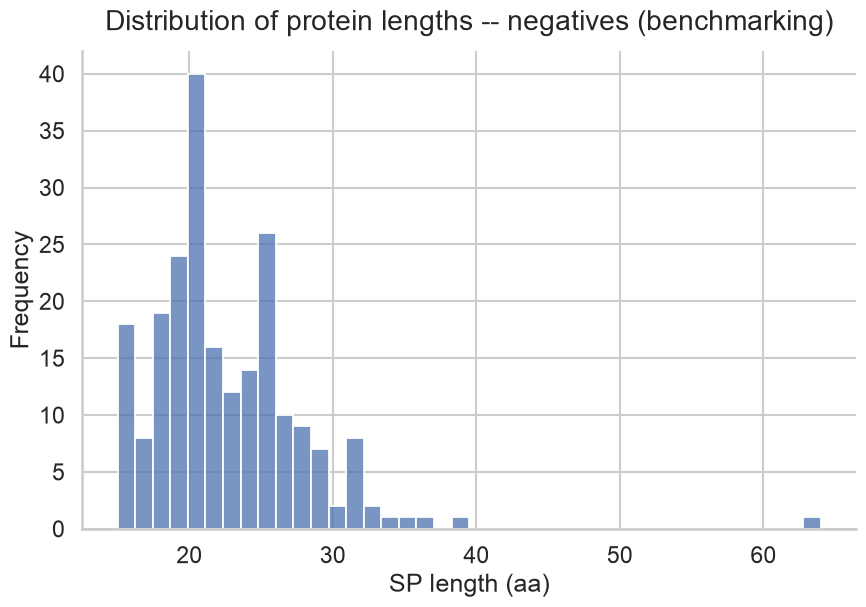

In [76]:
# SP LENGTHS DISTRIBUTION - BENCHMARKING
df = df_bn.dropna(subset=["label"]).copy()
df["label"] = df["label"].map({1.0: "Positive"})      # We set labels as strings
positives = df[df['label'] == 'Positive']

g = sns.displot(
    data=positives,
    x="cleavage_site",                                     
    bins=40,
    height=6,
    aspect=1.5,
)
g.set_axis_labels("SP length (aa)", "Frequency")
g.ax.set_title("Distribution of protein lengths -- negatives (benchmarking)", fontsize=20, pad=15)
plt.show()

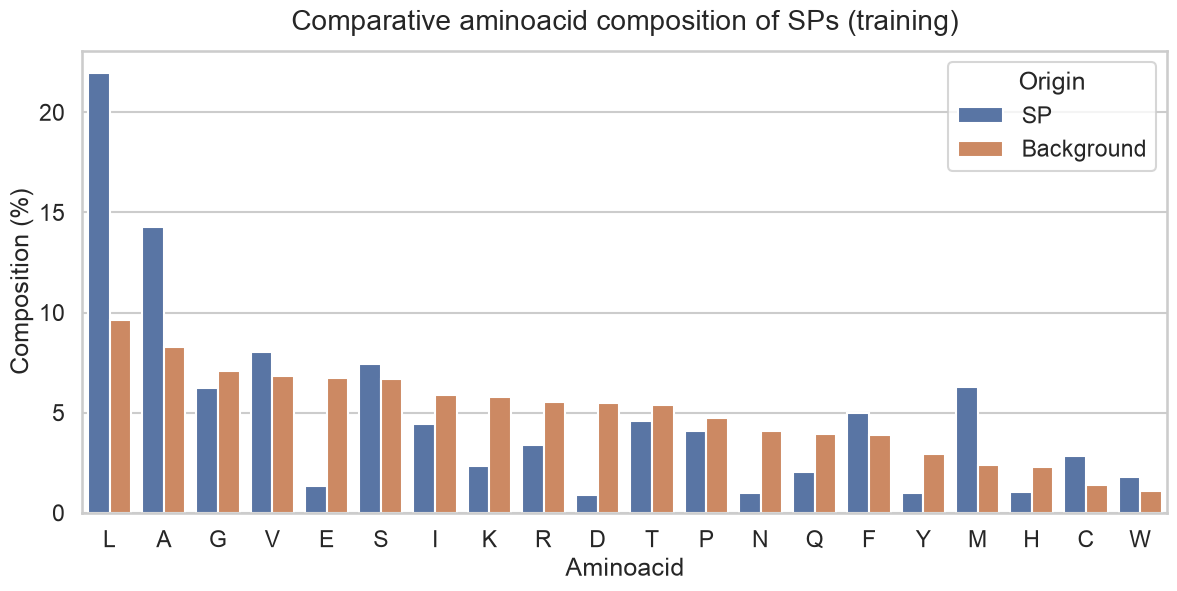

In [63]:
# COMPARATIVE ANALYSIS OF SP AMINOACID COMPOSITION - TRAINING
background = {
    "L": 9.65, "A": 8.26, "G": 7.07, "V": 6.85, "E": 6.71,
    "S": 6.67, "I": 5.90, "K": 5.79, "R": 5.53, "D": 5.46,
    "T": 5.37, "P": 4.75, "N": 4.06, "Q": 3.93, "F": 3.87,
    "Y": 2.92, "M": 2.41, "H": 2.28, "C": 1.39, "W": 1.11,
}

count = {aa: 0 for aa in background.keys()}

df = df_tr.dropna(subset=["sequence"])
positives = df[df["label"] == 1]

# Simultaneously checks sequence and cleavage site position to include only the SP
for seq, cleavage in zip(positives["sequence"], positives["cleavage_site"]):
    sp = seq[:int(cleavage)]
    for aa in sp:
        if aa in count:
            count[aa] += 1

# Converts counts to percentage
total = sum(count.values())
sp_percent = {aa: 100 * n / total for aa, n in count.items()}

comp = pd.DataFrame({
    "aa": list(background),
    "SP": [sp_percent[aa] for aa in background],
    "Background": list(background.values()),
})
comp_long = comp.melt(id_vars="aa", var_name="Origin", value_name="pct")

plt.figure(figsize=(14, 6))
sns.barplot(data=comp_long, x="aa", y="pct", hue="Origin")
plt.xlabel("Aminoacid")
plt.ylabel("Composition (%)")
plt.title("Comparative aminoacid composition of SPs (training)", fontsize=20, pad=15)
plt.show()


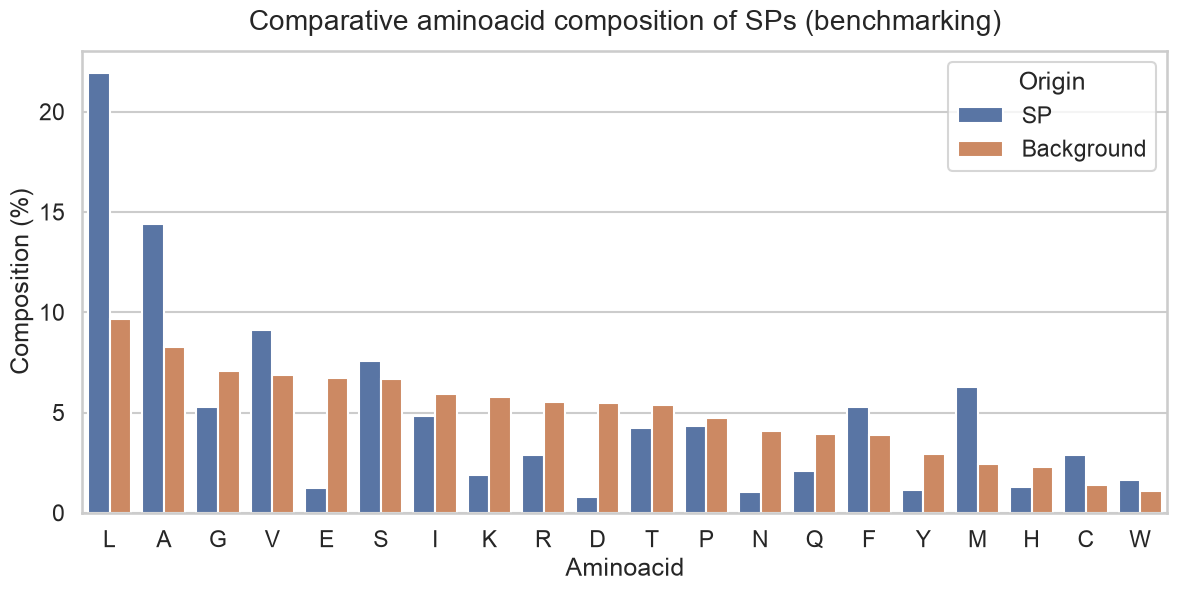

In [65]:
# COMPARATIVE ANALYSIS OF SP AMINOACID COMPOSITION - BENCHMARKING
background = {
    "L": 9.65, "A": 8.26, "G": 7.07, "V": 6.85, "E": 6.71,
    "S": 6.67, "I": 5.90, "K": 5.79, "R": 5.53, "D": 5.46,
    "T": 5.37, "P": 4.75, "N": 4.06, "Q": 3.93, "F": 3.87,
    "Y": 2.92, "M": 2.41, "H": 2.28, "C": 1.39, "W": 1.11,
}

count = {aa: 0 for aa in background.keys()}

df = df_bn.dropna(subset=["sequence"])
positives = df[df["label"] == 1]

# Simultaneously checks sequence and cleavage site position to include only the SP
for seq, cleavage in zip(positives["sequence"], positives["cleavage_site"]):
    sp = seq[:int(cleavage)]
    for aa in sp:
        if aa in count:
            count[aa] += 1

# Converts counts to percentage
total = sum(count.values())
sp_percent = {aa: 100 * n / total for aa, n in count.items()}

comp = pd.DataFrame({
    "aa": list(background),
    "SP": [sp_percent[aa] for aa in background],
    "Background": list(background.values()),
})
comp_long = comp.melt(id_vars="aa", var_name="Origin", value_name="pct")

plt.figure(figsize=(14, 6))
sns.barplot(data=comp_long, x="aa", y="pct", hue="Origin")
plt.xlabel("Aminoacid")
plt.ylabel("Composition (%)")
plt.title("Comparative aminoacid composition of SPs (benchmarking)", fontsize=20, pad=15)
plt.show()

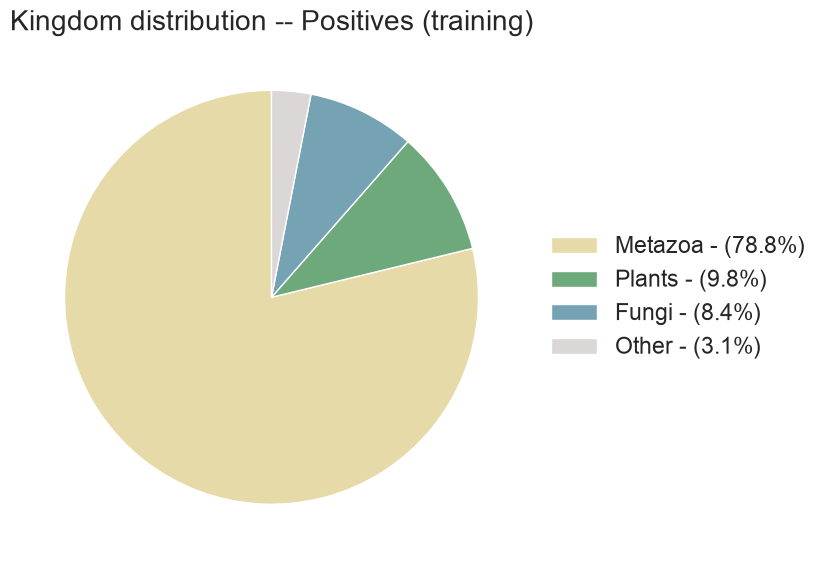

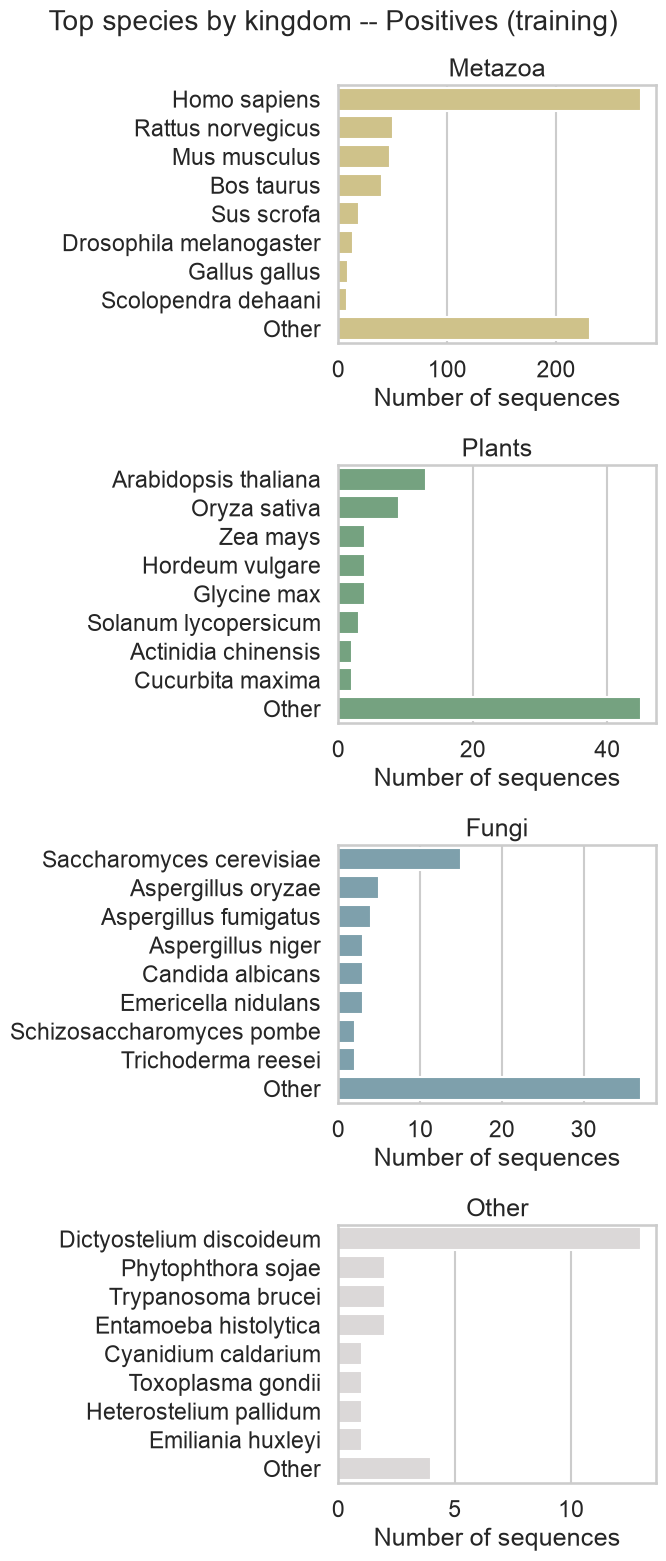

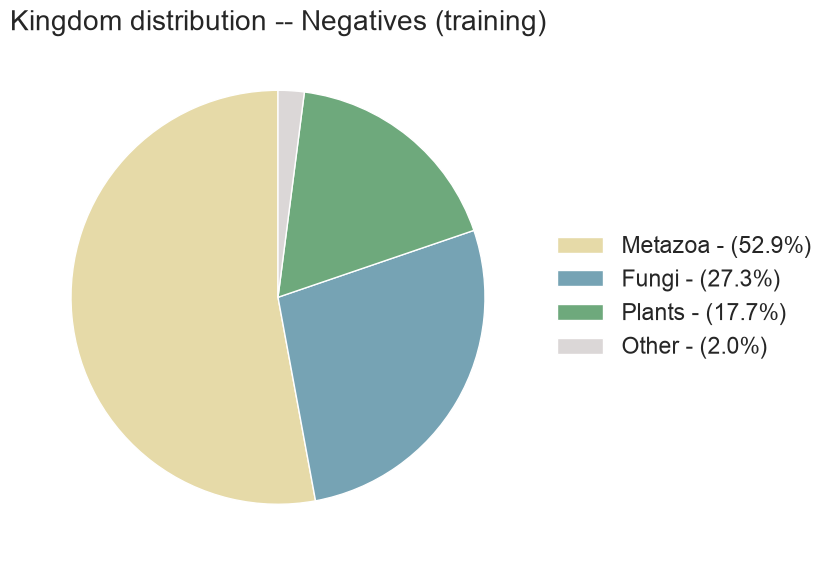

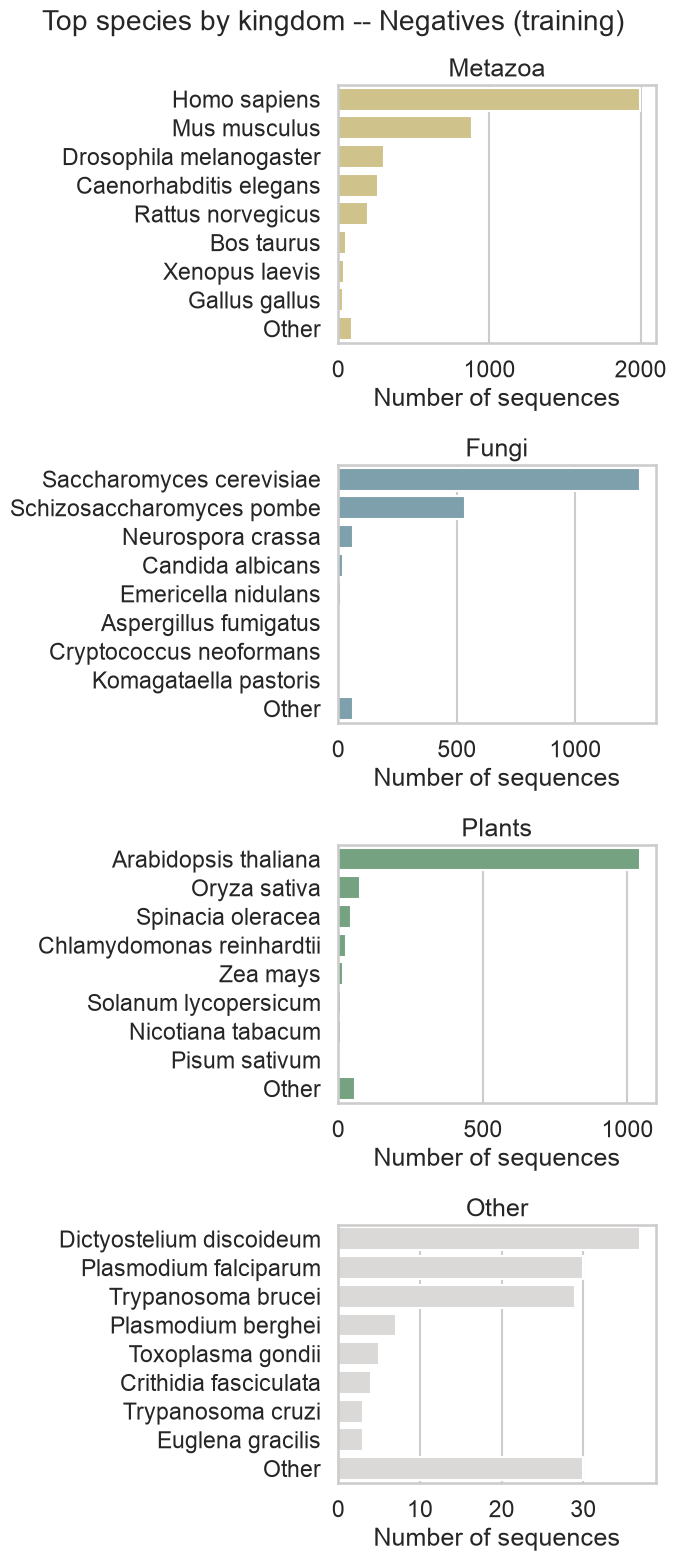

In [72]:
# TAXONOMIC CLASSIFICATION (Kingdoms and most frequent species) - TRAINING
df = df_tr.dropna(subset=["organism"])

kingdom_colors = {
    "Metazoa": "#DAC97FAC",
    "Plants":  "#6EA97C",
    "Fungi":   "#76A3B4",
    "Other":   "#DBD7D7",
}

TOP_N_SPECIES = 8

def plot_kingdom_pie(data, title):
    """Pie chart of the kingdom distribution, with counts and percentages in the legend."""
    counts = data["kingdom"].value_counts()
    colors = [kingdom_colors.get(k, "#999999") for k in counts.index]
    labels = [f"{k} - ({100 * v / counts.sum():.1f}%)" for k, v in counts.items()]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.pie(counts, colors=colors, startangle=90,
           wedgeprops={"edgecolor": "white", "linewidth": 1})
    ax.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
    ax.set_title(title, fontsize=20)
    plt.tight_layout()
    plt.show()

def plot_species_by_kingdom(data, title, top_n=TOP_N_SPECIES):
    """One bar panel per kingdom, stacked vertically, with the top N species and an 'Other' bar."""
    kingdoms = data["kingdom"].value_counts().index
    n = len(kingdoms)
    fig, axes = plt.subplots(n, 1, figsize=(7, 4 * n))     # vertical layout
    if n == 1:
        axes = [axes]
    for ax, kingdom in zip(axes, kingdoms):
        sub = data[data["kingdom"] == kingdom]
        scientific_name = sub["organism"].str.split().str[:2].str.join(" ")
        counts = scientific_name.value_counts()
        if len(counts) > top_n:
            top = counts.iloc[:top_n]
            other = pd.Series({"Other": counts.iloc[top_n:].sum()})
            counts = pd.concat([top, other])
        sns.barplot(x=counts.values, y=counts.index, ax=ax,
                    color=kingdom_colors.get(kingdom, "#999999"))
        if len(counts) < 3:
            ax.set_ylim(len(counts) - 0.5 + 4, -0.5 - 4) #fic to avoid big bars
        ax.set_title(kingdom)
        ax.set_xlabel("Number of sequences")
        ax.set_ylabel("")
    fig.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

for label, name in [(1, "Positives"), (0, "Negatives")]:
    subset = df[df["label"] == label]
    plot_kingdom_pie(subset, f"Kingdom distribution -- {name} (training)")
    plot_species_by_kingdom(subset, f"Top species by kingdom -- {name} (training)")

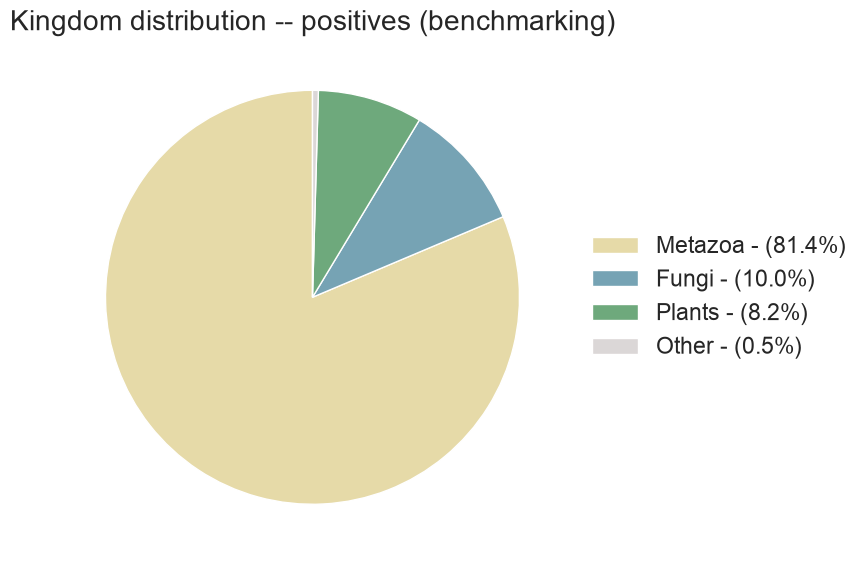

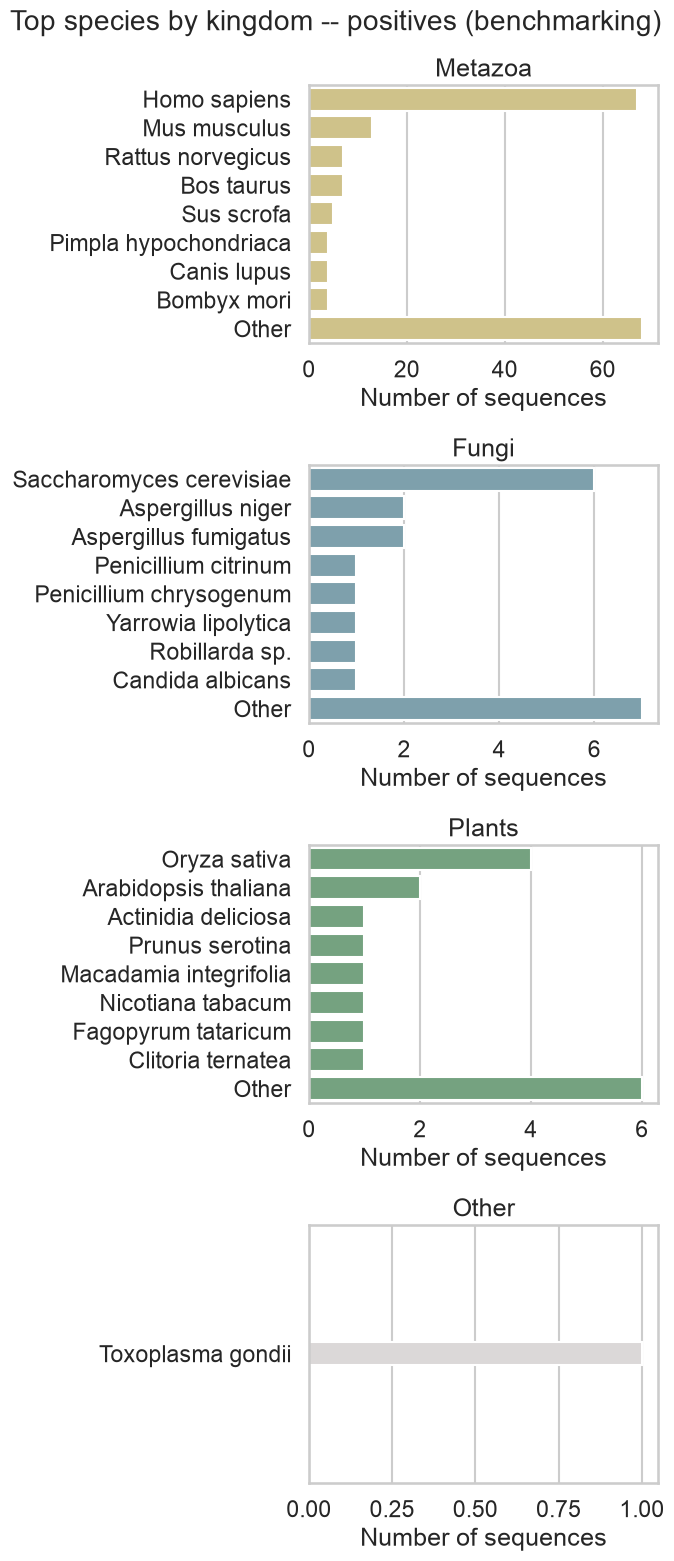

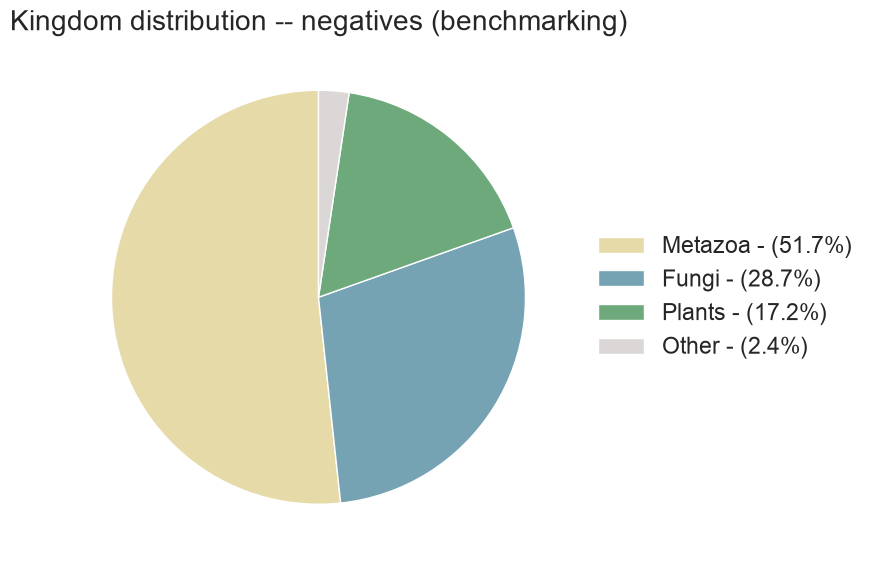

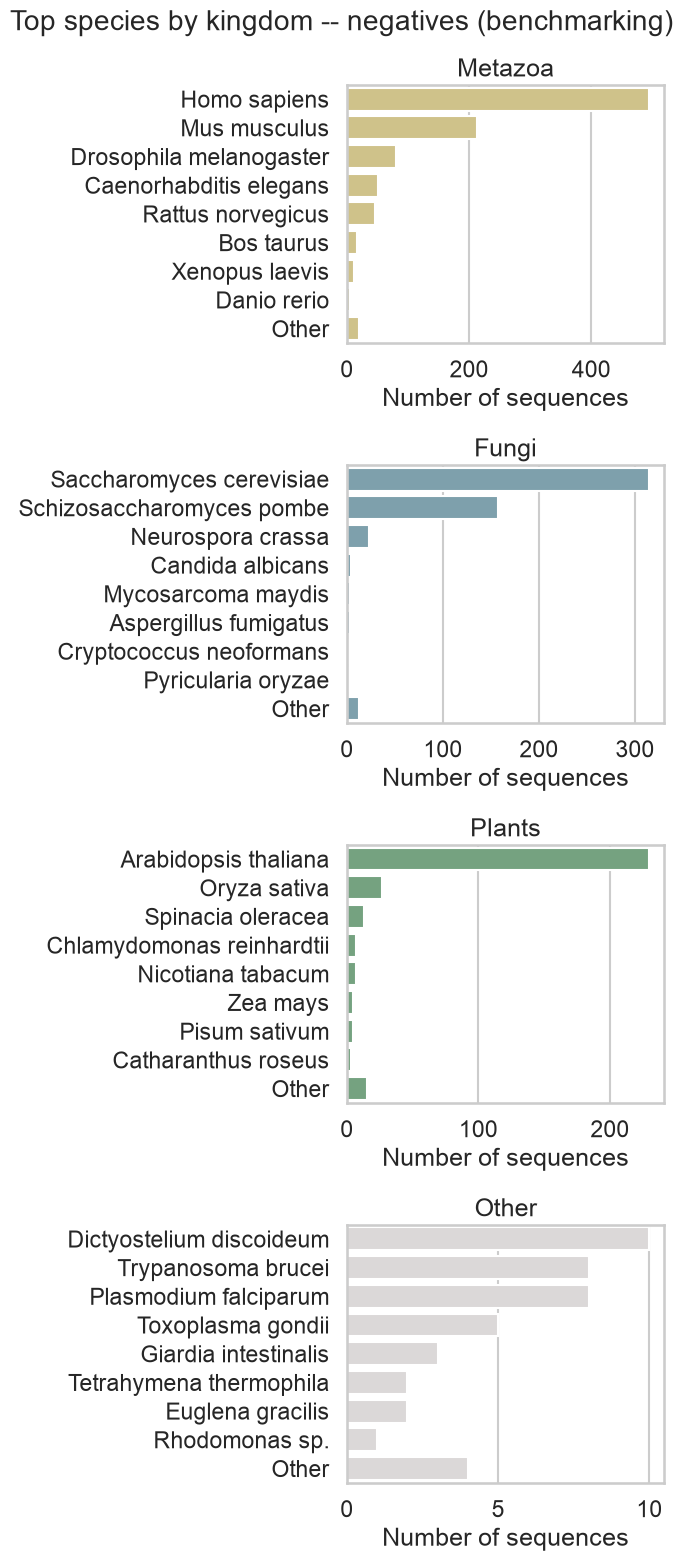

In [77]:
# TAXONOMIC CLASSIFICATION (Kingdoms and most frequent species) - BENCHMARKING
df = df_bn.dropna(subset=["organism"])

for label, name in [(1, "positives"), (0, "negatives")]:
    subset = df[df["label"] == label]
    plot_kingdom_pie(subset, f"Kingdom distribution -- {name} (benchmarking)")
    plot_species_by_kingdom(subset, f"Top species by kingdom -- {name} (benchmarking)")